In [1]:
# Code for figures + analysis in paper

# NB: Data sources are data.pkl, foraging_data.pkl, and bidding_data.pkl
# foraging_data is the trial-level data for the foraging task, and bidding_data is the trial-level data for the bidding task. 
# data.pkl is the subject-level data that includes demographics, cognitive test results, and MADRS score for each subject, as well as group labels.
# participants are labeled with subject ID 1XXX for controls and 2XXX for MDD patients.

# Created by: Aadith Vittala, April 20 2026
# Correspondence to: Aadith Vittala [aadith.vittala (at) nyulangone. org] or Paul Glimcher [pg3 (at) nyu. edu]

In [2]:
# import modules
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# setup seaborn for plotting
sns.reset_defaults()
sns.set_context('poster')
sns.set_palette(sns.color_palette(palette=['#ff7f0e','#7f7f7f','#1f77b4','#d62728']))

# Figure 2: Foraging task: Depressed patients (n=50) showed a higher reference point than healthy controls (n=70) and individual reference points in patients correlate with depressive severity.

## Figure 2b: Observed number of apples in a harvest that triggered the subject to leave for a new tree within a full block of trials (long-travel time condition) for a representative patient (orange) and healthy control (grey).

In [4]:
df = pd.read_pickle('foraging_data.pkl') # load data
df['id'] = df['id'].astype(int) # convert patient ID to integer for grouping
grouped = df.groupby(['id','date','patchBlock']) # group data by patient ID and date and block
left_thresholds = pd.DataFrame() # save all data one before a leave tree action
for name, group in grouped:
    pt_id = name[0]
    date = name[1]
    leftNum = 0 # threshold number in each block
    for i in group.index: # for each row in group
        if group.loc[i, 'decision'] == 'exit': # if exited
            leftNum += 1
            one_row_before = group.loc[i-1:i-1,:].copy()
            one_row_before['leftNum'] = leftNum
            left_thresholds = pd.concat((left_thresholds, one_row_before)) # add data from one row before

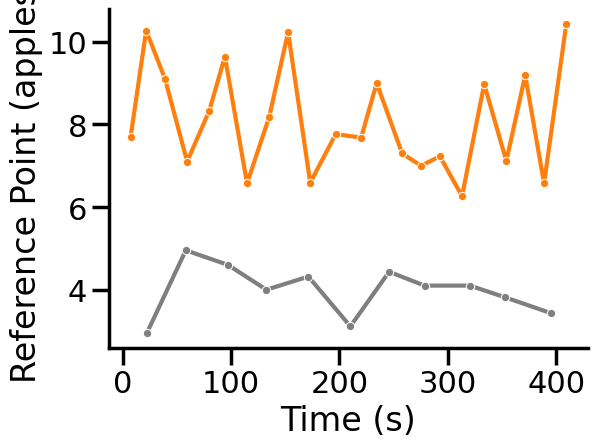

In [5]:

idnums = [2060,1038] # sample ID numbers for plotting (one HC, one MDD)

indices = (left_thresholds['id'] == idnums[0]) # select only this data to plot
for i in range(1,len(idnums)):
	indices = indices | (left_thresholds['id'] == idnums[i])

# plot leaving thresholds for the first block for the two sample participants
g = sns.relplot(data=left_thresholds[indices&(left_thresholds['patchBlock']==1)], x='blockTime',y='reward', hue='id', style='id',kind='line', markers=['.','.'], dashes=['',''], palette=['#ff7f0e','#7f7f7f'], legend=False, aspect=1.3)
g.set_axis_labels("Time (s)","Reference Point (apples)")
plt.show()

# save figure if necessary
# plt.rcParams['svg.fonttype'] = 'none'
# g.savefig('fig.svg')


## Figure 2c: Average number of apples that triggers leaving, across all blocks and participants.

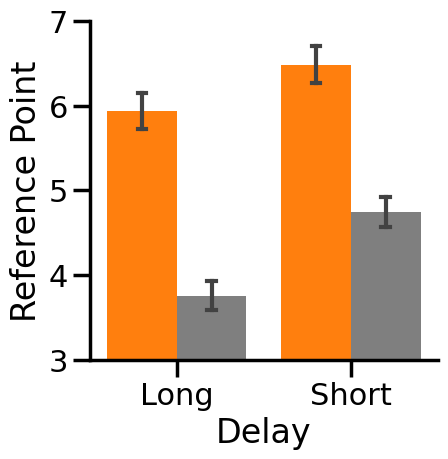

2-sample t-test (Long): TtestResult(statistic=np.float64(7.953828688620031), pvalue=np.float64(6.121527106579256e-13), df=np.float64(118.0))
2-sample t-test (Short): TtestResult(statistic=np.float64(6.307836925458326), pvalue=np.float64(2.5562359267541107e-09), df=np.float64(118.0))


In [6]:
data = pd.read_pickle('data.pkl')
sns.reset_defaults()
sns.set_context('poster')
sns.set_palette(sns.color_palette(palette=['#ff7f0e','#7f7f7f','#1f77b4','#d62728']))
df = data[['group','thresh_long','thresh_short']].copy()
df.loc[df['group']=='mdd','group'] = 'MDD'
df.loc[df['group']=='control','group'] = 'HC'
df = df.rename(columns={'group':'Group','thresh_long':'Long','thresh_short':'Short'})
df = df.melt(id_vars=['Group'], value_vars=['Long','Short'], var_name='Delay', value_name='Reference Point')
fig = sns.catplot(data=df, x='Delay', y='Reference Point', errorbar='se', hue='Group', kind='bar', capsize=0.1, saturation=1.0, err_kws={'linewidth': 3.0}, legend=False)
plt.ylim((3,7))
plt.show()


# print out statistics
from scipy.stats import ttest_ind
print("2-sample t-test (Long):", ttest_ind(data[data['group']=='mdd']['thresh_long'], data[data['group']=='control']['thresh_long'], alternative='greater'))
print("2-sample t-test (Short):", ttest_ind(data[data['group']=='mdd']['thresh_short'], data[data['group']=='control']['thresh_short'], alternative='greater'))

# save figure if necessary
# fig.savefig('out.png',dpi=300)
# plt.rcParams['svg.fonttype'] = 'none'
# fig.savefig('fig.svg')



## Figure 2d: Distribution of average long-travel block leaving points for individual patients and healthy controls.

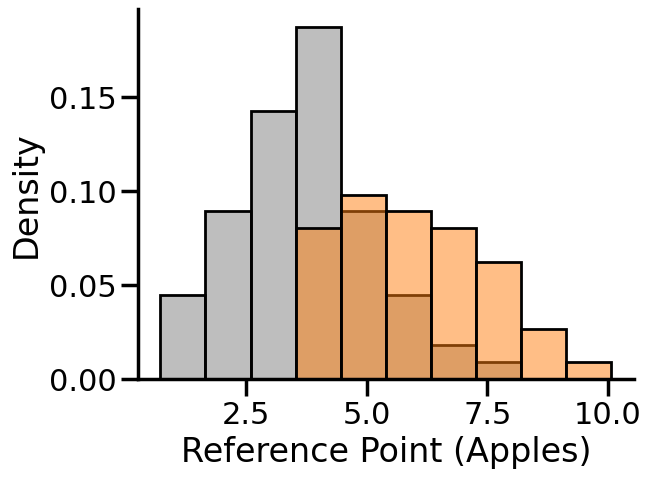

2-sample Kolmogorov-Smirnov test: KstestResult(statistic=np.float64(0.5685714285714286), pvalue=np.float64(3.0977666802835015e-09), statistic_location=np.float64(4.420930560630425), statistic_sign=np.int8(-1))


In [7]:
data = pd.read_pickle('data.pkl')

sns.reset_defaults()
sns.set_context('poster')
sns.set_palette(sns.color_palette(palette=['#ff7f0e','#7f7f7f','#1f77b4','#d62728']))
fig = sns.histplot(data=data, x='thresh_long', hue='group', stat='density', pmax=1.0)
fig.spines['top'].set_visible(False)
fig.spines['right'].set_visible(False)
fig.legend_.remove()
plt.xlabel('Reference Point (Apples)')
plt.show()

# save figure if necessary
# plt.rcParams['svg.fonttype'] = 'none'
# plt.savefig('fig.svg')


# print out statistics:
from scipy.stats import kstest
print('2-sample Kolmogorov-Smirnov test:', kstest(data[data['group']=='mdd']['thresh_long'], data[data['group']=='control']['thresh_long']))

## Figure 2e: Area Under the Curve analysis (AUC) using average long-travel block leaving point to predict whether participants are control or MDD

thresh_long 0.8545714285714285


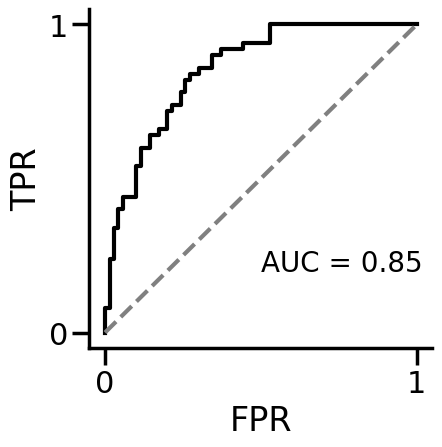

In [8]:
from sklearn.metrics import roc_curve, roc_auc_score
sns.reset_defaults()
sns.set_palette(sns.color_palette(palette=['#000000','#ff7f0e','#1f77b4','#d62728']))
sns.set_context('poster')
data = pd.read_pickle('data.pkl')
predictors = ['thresh_long']
for pred in predictors:
	mdd_pred = data[data['group']=='mdd'][pred].to_list()
	control_pred = data[data['group']=='control'][pred].to_list()
	fpr, tpr, ts = roc_curve([0]*len(control_pred)+[1]*len(mdd_pred), control_pred+mdd_pred)
	auc = roc_auc_score([0]*len(control_pred)+[1]*len(mdd_pred), control_pred+mdd_pred)
	auc_curve = pd.DataFrame(np.array([fpr,tpr]).T, columns=['FPR','TPR'])
	
	fig = sns.relplot(data=auc_curve, x='FPR', y='TPR', estimator=None, kind='line', aspect=1.1)
	sns.lineplot(ax=fig.ax)
	fig.ax.set_xticks([0,1])
	fig.ax.set_yticks([0,1])
	fig.ax.plot(np.linspace(0,1), np.linspace(0,1),color='grey',linestyle='--')
	plt.text(0.5, 0.2, f'AUC = {auc:.2f}', fontsize=20)
	print(pred, auc)
	# save figure if necessary
	# plt.rcParams['svg.fonttype'] = 'none'
	# fig.savefig('fig.svg')
	# fig.savefig('out.png',dpi=300)
plt.show()



In [9]:
# calculate AUC versus time for the first block

foraging_calcs = pd.read_pickle('foraging_data.pkl')
data = pd.read_pickle('data.pkl')
foraging_calcs['id'] = foraging_calcs['id'].astype(int)
foraging_data = pd.merge(data[['id','group']], foraging_calcs, on='id',how='left') # cut to only data for valid participants

grouped = foraging_data.groupby(['id','date','patchBlock']) # group data by patient ID and date and block
left_thresholds = pd.DataFrame() # select all data one before a leave tree action
for name, group in grouped:
    pt_id = name[0]
    date = name[1]
    leftNum = 0 # threshold number in each block
    for i in group.index: # for each row in group
        if group.loc[i, 'decision'] == 'exit': # if exited
            leftNum += 1
            one_row_before = group.loc[i-1:i-1,:].copy()
            one_row_before['leftNum'] = leftNum
            left_thresholds = pd.concat((left_thresholds, one_row_before)) # add data from one row before


dyn_data = left_thresholds.copy()[['patchState', 'blockName','blockTime','patchBlock','time','reward','id','date','leftNum','totalCents']]
dyn_data.loc[:,'group'] = 'mdd'
dyn_data.loc[(dyn_data['id'] >= 2000),'group'] = 'control'
dyn_data['blockTimeBinned'] = (dyn_data['blockTime']//40)*40

# add modifier to show whether data is for firstBlock is a short block or a long block
dyn_data['firstBlock'] = 'short'
first_block_long_IDs = dyn_data[(dyn_data['blockName'] == 'long')&(dyn_data['patchBlock']==1)]['id'].unique()
dyn_data.loc[dyn_data['id'].isin(first_block_long_IDs), 'firstBlock'] = 'long'
dyn_data['firstBlock'].value_counts()

# add total time by multiplying number of blocks (minus 1) by 420 and adding to time (since all blocks are 420 seconds at most)
dyn_data['totalTime'] = 420*(dyn_data['patchBlock']-1) + dyn_data['blockTime']
dyn_data['totalTimeBinned'] = (dyn_data['totalTime']//60)*60

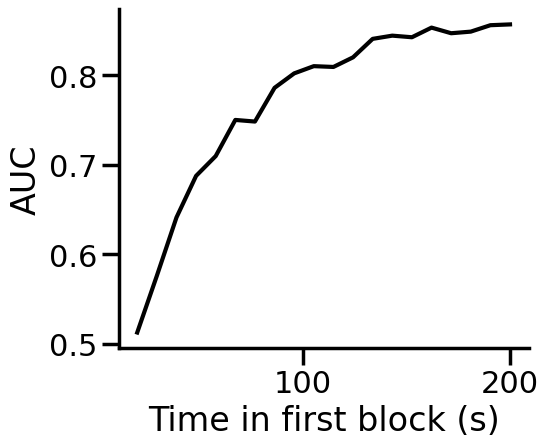

In [10]:
# plot AUC versus time for the first block
from sklearn.metrics import roc_curve, roc_auc_score
data_block1 = dyn_data[dyn_data['patchBlock']==1].copy()
time_thresh = np.linspace(20,200,num=20)
short_block_classify = []
long_block_classify = []
for thresh in time_thresh: # test classification by cutting data to each of these time thresholds
	df_cut = data_block1[data_block1['blockTime'] < thresh]
	df_cut = df_cut.groupby(['group','id','blockName'])['reward'].agg('mean').reset_index() # mean leaving threshold
	mdd_pred_short = df_cut[(df_cut['group']=='mdd')&(df_cut['blockName']=='short')]['reward'].to_list()
	control_pred_short = df_cut[(df_cut['group']=='control')&(df_cut['blockName']=='short')]['reward'].to_list()
	mdd_pred_long = df_cut[(df_cut['group']=='mdd')&(df_cut['blockName']=='long')]['reward'].to_list()
	control_pred_long = df_cut[(df_cut['group']=='control')&(df_cut['blockName']=='long')]['reward'].to_list()
	fpr, tpr, ts = roc_curve([0]*len(control_pred_short)+[1]*len(mdd_pred_short), control_pred_short+mdd_pred_short)
	auc = roc_auc_score([0]*len(control_pred_short)+[1]*len(mdd_pred_short), control_pred_short+mdd_pred_short)
	short_block_classify.append(auc)
	fpr, tpr, ts = roc_curve([0]*len(control_pred_long)+[1]*len(mdd_pred_long), control_pred_long+mdd_pred_long)
	auc = roc_auc_score([0]*len(control_pred_long)+[1]*len(mdd_pred_long), control_pred_long+mdd_pred_long)
	long_block_classify.append(auc)

auc_df = pd.DataFrame({'Time in first block (s)':list(time_thresh)+list(time_thresh), 
		'AUC':short_block_classify+long_block_classify, 
		'Block':['short']*len(time_thresh)+['long']*len(time_thresh)})
sns.set_palette(sns.color_palette(palette=['#000000','#d62728','#1f77b4']))
# only plot for long block
fig = sns.relplot(auc_df[auc_df['Block']=='long'], x='Time in first block (s)', y='AUC', kind='line', aspect=1.2, legend=False)
fig.ax.set_xticks([100,200])
plt.show()
# plt.rcParams['svg.fonttype'] = 'none'
# plt.savefig('fig.svg')




## Figure 2f: Individual average leaving times among patients (long-travel blocks shown) correlate with symptom severity by MADRS score.

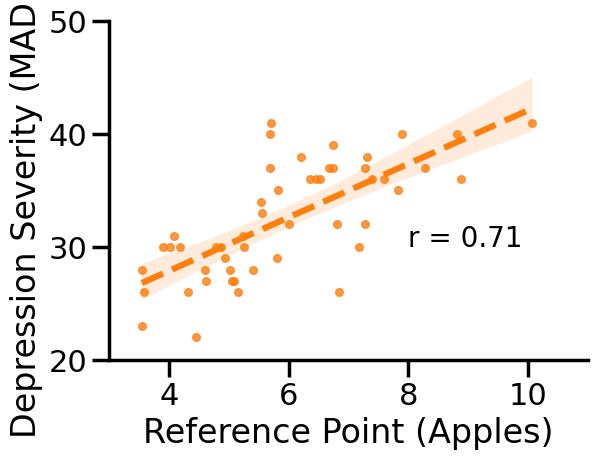

Pearson correlation: PearsonRResult(statistic=np.float64(0.7143159013073312), pvalue=np.float64(5.709898786727507e-09))


In [11]:
# for poster
from scipy import stats
sns.reset_defaults()
sns.set_palette(sns.color_palette(palette=['#ff7f0e','#7f7f7f','#1f77b4','#d62728']))
sns.set_context('poster')
data = pd.read_pickle('data.pkl')
df = data[data['group']=='mdd'][['madrs_score','thresh_long']].copy()
df = df.rename(columns={'thresh_long':'Reference Point','madrs_score':'Depression Severity (MADRS)'})
fig = sns.lmplot(data=df, x='Reference Point', y='Depression Severity (MADRS)', scatter_kws={'s': 30},line_kws={'linestyle':'--'}, aspect=1.3)
plt.xlim((3,11))
plt.ylim((20,50))
plt.xlabel('Reference Point (Apples)')
r_value, _ = stats.pearsonr(df["Reference Point"], df["Depression Severity (MADRS)"])
plt.text(8, 30, f'r = {r_value:.2f}', fontsize=20)
plt.show()

# print statistics for correlation
print('Pearson correlation:', stats.pearsonr(df["Reference Point"], df["Depression Severity (MADRS)"]))

# save figure if necessary
# plt.rcParams['svg.fonttype'] = 'none'
# fig.savefig('fig.svg')
# fig.savefig('out.png',dpi=300)
# sns.reset_defaults()




# Figure 3: Bidding Task: Depressed patients (n=50) show a reduced ability to meaningfully adapt their reference points to a changing environment compared to healthy controls (n=70). 

## Figure 3b: Average bid shifts (in negative dollars, over 90 bids/5 min, error bars are 95% confidence intervals) return back to baseline after exposure to a better (high, red) or worse (low, blue) environment. Unlike healthy controls, patients show no significant relaxation of their bids back to preadaptation levels during the 90 trial (5m) measurement interval.

In [15]:
# exponential fits via MLE
data_bidding = pd.read_pickle('bidding_data.pkl')

# fit to raw data for each group together
from scipy.optimize import curve_fit
from scipy.optimize import minimize
# The model function: y = a * e^(-b * x)
# Define log likelihood for y = a exp(-b x)
def log_like(params, x, y):
    sigma = params[2]
    yhat = params[0]*np.exp(-params[1]*x)
    return len(y)*np.log(sigma*sigma) + np.sum((y - yhat)**2)/(sigma*sigma)

# Define log likelihood for y = a
def log_like_constant(params, x, y):
    sigma = params[1]
    yhat = params[0]
    return len(y)*np.log(sigma*sigma) + np.sum((y - yhat)**2)/(sigma*sigma)

# fit each of blocks 2, 3, and 4 from each participant and store parameters
params = pd.DataFrame()
grouped = data_bidding[data_bidding['block_meaning'] != 'initial'].groupby(['group','block_meaning'])
for name, data_group in grouped:
    group, block_meaning = name
    x_data = np.array(data_group['trial_in_block'])
    y_data = np.array(data_group['dev_from_lb'])
    res = minimize(log_like, [0,0.1,1.0], args=(x_data, y_data))
    res_const= minimize(log_like_constant, [0,1.0], args=(x_data, y_data))
    a, b, sigma = res.x
    aic_exp = 2*2 + 2*res.fun
    a_const, sigma_const = res_const.x
    aic_const = 2*1 + 2*res_const.fun
    data_row = [['exp', group, block_meaning, a, b, sigma, res.fun, aic_exp]]
    data_row = pd.DataFrame(data_row, columns=['model','group','block_meaning','param_a','param_b','sigma','log_like','aic'])
    params = pd.concat((params, data_row)) # add data
    data_row = [['const', group, block_meaning, a_const, 0, sigma_const, res_const.fun, aic_const]]
    data_row = pd.DataFrame(data_row, columns=['model','group','block_meaning','param_a','param_b','sigma','log_like','aic'])
    params = pd.concat((params, data_row)) # add data

params

,model,group,block_meaning,param_a,param_b,sigma,log_like,aic
0,exp,control,post_high,-0.114180,0.042318,0.710956,1972.982052,3949.964103
0,const,control,post_high,-0.036193,0.000000,0.711188,1977.027160,3956.054321
0,exp,control,post_low,0.092178,0.019402,0.631397,497.989488,999.978977
0,const,control,post_low,0.043765,0.000000,0.631717,504.257861,1010.515722
0,exp,patient,post_high,-0.136500,-0.003150,0.821617,2731.673908,5467.347816
0,const,patient,post_high,-0.158076,0.000000,0.821717,2732.765897,5467.531793
0,exp,patient,post_low,0.166969,0.001236,0.836162,2889.602943,5783.205887
0,const,patient,post_low,0.157916,0.000000,0.836178,2889.773163,5781.546326


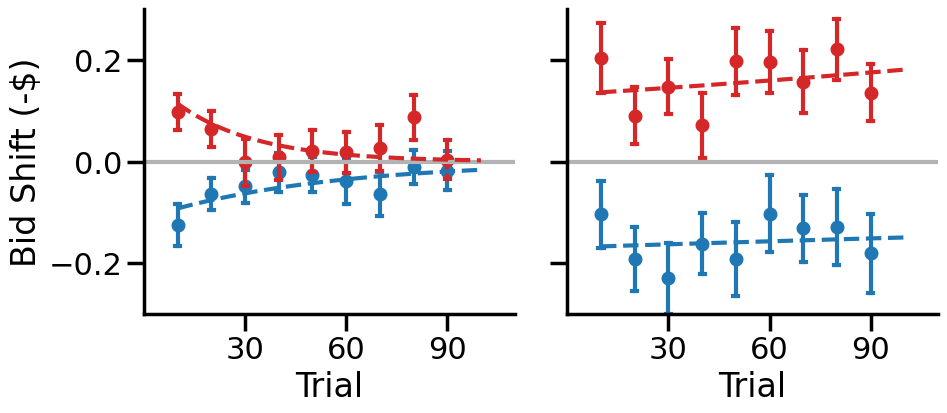

In [16]:
# plot for manuscript
# average within subject out (so better error bars)
# add in exponential fits
# use negative bid deviation = RP shift
data_bidding_by_sub = data_bidding.groupby(['binned_trial','block_meaning','group','subid'])['dev_from_lb'].agg('mean').reset_index()
sns.set_palette(sns.color_palette(palette=['#1f77b4','#d62728']))
data_bidding_by_sub = data_bidding_by_sub[data_bidding_by_sub['block_meaning'] != 'initial']
data_bidding_by_sub = data_bidding_by_sub.rename(columns={'dev_from_lb':'Bid deviation ($)', 'binned_trial':'Trial'})
data_bidding_by_sub['Bid Shift (-$)'] = -data_bidding_by_sub['Bid deviation ($)']
g = sns.catplot(data=data_bidding_by_sub, x='Trial', y='Bid Shift (-$)', hue='block_meaning',col='group',col_order=['control','patient'],hue_order=['post_low','post_high'],kind='point',errorbar='se',native_scale=True,linestyle='none',markersize=6,capsize=0.15,err_kws={'linewidth':3},legend=False)
g.map(plt.axhline, y=0.0, color='.7')
x = np.linspace(0,90)
hc_ph = 0.114180*np.exp(-x*0.042318)
hc_pl = -0.092178*np.exp(-x*0.019402)
mdd_ph = 0.136500*np.exp(x*0.003150)
mdd_pl = -0.166969*np.exp(-x*0.001236)

g.axes.flat[0].plot(x, hc_ph, color='#d62728', linestyle='--')
g.axes.flat[0].plot(x, hc_pl, color='#1f77b4', linestyle='--')
g.axes.flat[1].plot(x, mdd_ph, color='#d62728', linestyle='--')
g.axes.flat[1].plot(x, mdd_pl, color='#1f77b4', linestyle='--')
for ax in g.axes.flat:
	ax.set_xticks([20,50,80])
	ax.set_xticklabels([30,60,90])
	ax.set_title('')
	ax.set_ylim([-0.3,0.3])
	ax.set_xlim([-10,100])
plt.show()
# plt.rcParams['svg.fonttype'] = 'none'
# g.savefig('fig.svg')
# g.savefig('fig.png', dpi=300)

In [17]:
# bootstrap to find significance of exponential model fit
# find probability b > 0

import warnings
warnings.filterwarnings('ignore')

# fit to raw data for each group together
from scipy.optimize import minimize

# Define log likelihood for y=a exp(-b x)
def log_like(params, x, y):
    sigma = params[2]
    yhat = params[0]*np.exp(-params[1]*x)
    # yhat = params[0] + (-params[1]*x)
    return len(yhat)*np.log(sigma*sigma) + np.sum((y - yhat)**2)/(sigma*sigma)


# fit each of blocks 2, 3, and 4 from each participant and store parameters
params = {}
rng = np.random.default_rng()
grouped = data_bidding[data_bidding['block_meaning'] != 'initial'].groupby(['group','block_meaning'])
for name, data_group in grouped:
    group, block_meaning = name
    params[(group, block_meaning, 'bootstrap_a')] = []
    params[(group, block_meaning, 'bootstrap_b')] = []
    print(group, block_meaning)
    x_data = np.array(data_group['trial_in_block'])
    y_data = np.array(data_group['dev_from_lb'])
    for i in range(2000):
        print(i,end="\r")
        bootstrapped_sample = rng.choice([x_data, y_data], axis=1, size=len(x_data))
        x_bootstrap = bootstrapped_sample[0,:]
        y_bootstrap = bootstrapped_sample[1,:]
        res = minimize(log_like, [0,0.1,1.0], args=(x_bootstrap, y_bootstrap))
        a, b = res.x[0], res.x[1]
        params[(group, block_meaning, 'bootstrap_a')].append(a)
        params[(group, block_meaning, 'bootstrap_b')].append(b)

print("Group", "Block", "Mean b", "Std b", "P(b < 0)")
for group in ['control','patient']:
	for block in ['post_high','post_low']:
		print(group, block, np.mean(np.array(params[group,block,'bootstrap_b'])), np.std(np.array(params[group,block,'bootstrap_b'])), 
		np.mean(np.array(params[group,block,'bootstrap_b']) < 0))

control post_high
control post_low
patient post_high
patient post_low
Group Block Mean b Std b P(b < 0)
control post_high 0.06950518545881491 0.6174847891408554 0.05
control post_low 0.35870639277643485 2.037592035099007 0.0145
patient post_high -0.0028899171352832786 0.004417436043182382 0.8475
patient post_low 0.001156182891379008 0.00293719779498611 0.3415


## Figure 3c: Residual reference point shift observed during the last ten trials of a measurement block (gray area in panel B) is significantly different between patients and healthy controls. 

2-sample t-test for post-high blocks:
TtestResult(statistic=np.float64(-2.011150689823742), pvalue=np.float64(0.023304112085704914), df=np.float64(117.0))
2-sample t-test for post-low blocks:
TtestResult(statistic=np.float64(2.038936769112494), pvalue=np.float64(0.021864621774638545), df=np.float64(116.0))


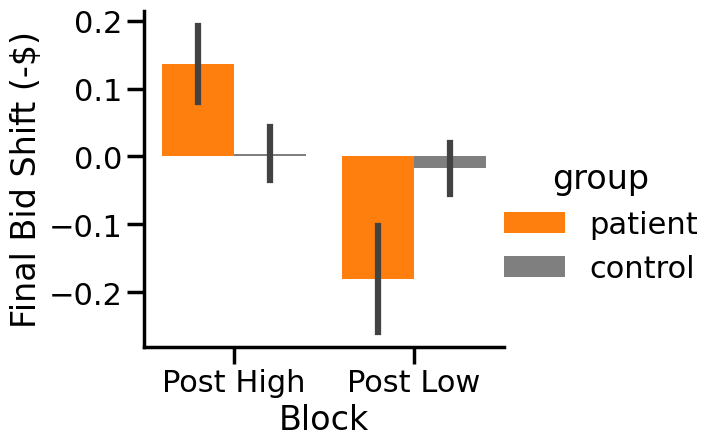

In [18]:
# plot for manuscript, above but only for last block
data_bidding = pd.read_pickle('bidding_data.pkl')
# average within subject out (so correct error bars)
data_bidding_by_sub = data_bidding.groupby(['binned_trial','block_meaning','group','subid'])['dev_from_lb'].agg('mean').reset_index()
data_bidding_by_sub = data_bidding_by_sub[data_bidding_by_sub['block_meaning'] != 'initial'] # keep only post high/post low blocks
data_bidding_by_sub = data_bidding_by_sub.rename(columns={'dev_from_lb':'Bid deviation ($)', 'binned_trial':'Trial'})
data_bidding_by_sub['Bid Shift (-$)'] = data_bidding_by_sub['Bid deviation ($)']*-1 # add column for bid shift (negative of bid deviation)

sns.reset_defaults()
sns.set_context('poster')
sns.set_palette(sns.color_palette(palette=['#ff7f0e','#7f7f7f','#1f77b4','#d62728']))
g = sns.catplot(data=data_bidding_by_sub[data_bidding_by_sub['Trial']==80],y='Bid Shift (-$)', x='block_meaning',hue='group',hue_order=['patient','control'],kind='bar',aspect=1.2,errorbar='se',saturation=1.0)#,native_scale=True,linestyle='none',markersize=6,capsize=0.15,err_kws={'linewidth':3},col_order=['control','patient'],hue_order=['post_low','post_high'])
plt.ylabel('Final Bid Shift (-$)')
plt.xlabel('Block')
plt.xticks(ticks=[0,1],labels=['Post High','Post Low'])

# print t-test statistics for group differences
import scipy.stats as stats
df_high = data_bidding_by_sub[(data_bidding_by_sub['Trial']==80)&(data_bidding_by_sub['block_meaning']=='post_high')]
df_low = data_bidding_by_sub[(data_bidding_by_sub['Trial']==80)&(data_bidding_by_sub['block_meaning']=='post_low')]
print('2-sample t-test for post-high blocks:')
print(stats.ttest_ind(df_high[df_high['group']=='patient']['Bid deviation ($)'], df_high[df_high['group']=='control']['Bid deviation ($)'], alternative='less'))
print('2-sample t-test for post-low blocks:')
print(stats.ttest_ind(df_low[df_low['group']=='patient']['Bid deviation ($)'], df_low[df_low['group']=='control']['Bid deviation ($)'], alternative='greater'))

# save figure if necessary
# plt.rcParams['svg.fonttype'] = 'none'
# g.savefig('fig.svg')
plt.show()

## Figure 3d: The magnitude of this residual shift after 80 measurements (post-high adaptation shown) is correlated with depression severity in patients

Pearson r: 0.3912810957583514 p-value: 0.004957606703357584


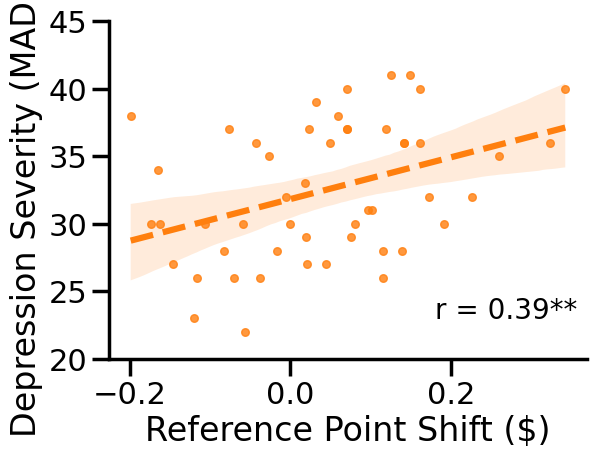

In [19]:
# for manuscript
from scipy import stats
sns.reset_defaults()
sns.set_palette(sns.color_palette(palette=['#ff7f0e','#7f7f7f','#1f77b4','#d62728']))
sns.set_context('poster')


# find summary of deviations in last ten trials
def last_ten(x):
	if len(x) < 10:
		return np.nan
	return np.average(x[-10:])
data_bidding = pd.read_pickle('bidding_data.pkl')
summary_bidding = data_bidding.groupby(['subid','sequence','block','block_meaning','group'])['norm_dev_from_lb'].agg([last_ten]).reset_index()
summary_bidding['id'] = summary_bidding['subid']
summary_bidding.drop(columns=['group'],inplace=True) # drop to then merge with data.pkl
data_foraging = pd.read_pickle('data.pkl')
all_data = pd.merge(summary_bidding, data_foraging, on='id', how='left')
post_high_data = all_data[(all_data['block_meaning']=='post_high')&(all_data['group']=='mdd')] # keep only post high for mdd group
df = post_high_data[['madrs_score','last_ten']].copy()
df['rp_shift_last_ten'] = -df['last_ten']
fig = sns.lmplot(data=df, x='rp_shift_last_ten', y='madrs_score', scatter_kws={'s': 30}, line_kws={'linestyle':'--'}, aspect=1.3)
fig.set_ylabels('Depression Severity (MADRS)')
fig.set_xlabels('Reference Point Shift ($)')
plt.ylim([20,45])
r_value, p_val = stats.pearsonr(df["rp_shift_last_ten"], df["madrs_score"])
print("Pearson r:", r_value, "p-value:", p_val)
plt.text(0.18, 23, f'r = {r_value:.2f}**', fontsize=20)
plt.rcParams['svg.fonttype'] = 'none'
plt.show()

# save figure if necessary
# fig.savefig('fig.svg')
# # fig.savefig('out.png',dpi=300)
# # sns.reset_defaults()

# Supplement Figures

## Fig S1: Depressed participants and healthy controls had similar average amounts earned because controls tended to overharvest and depressed participants tended to underharvest.

Optimal threshold: 4.544897959183674 gives reward $ 13.054736950142019 and has optimal apples/sec 1.5541353512073832


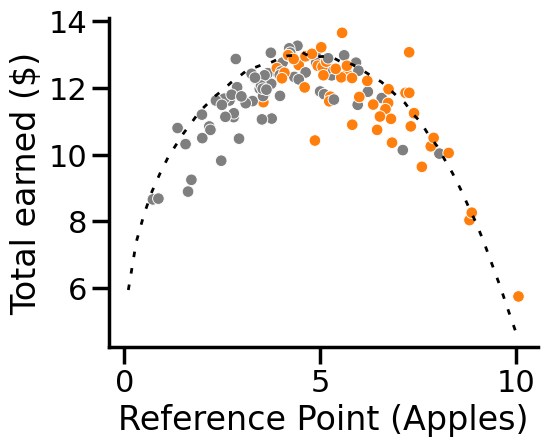

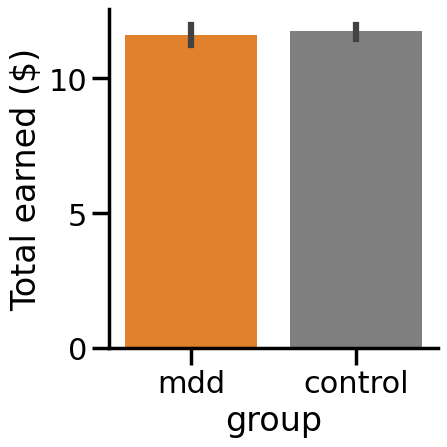

2-sample t-test for total earned:
TtestResult(statistic=np.float64(-0.5521785193507669), pvalue=np.float64(0.2909351979271598), df=np.float64(118.0))


In [20]:
# Foraging generative parameters
alpha = 14.90873 # parameters to randomly select depletion rate
beta = 2.033008
r0_m = 10 # mean number of apples at first
r0_s = 1 # standard deviation of apples at first
apple_price = 1.0/100 # in dollars

# Foraging timing parameters
# Time in between is: d=4.3/11.4 and t=3.06
t = 3.06 # including apple show, delay to decision, and too slow times
d = 11.4  # travel time + delay to decision and too slow and apple display times

# run with shaking threshold for the amount of time specified
# return total rewards accumulated
def runUsingThreshold(thresh, max_time=420):
	time_left = max_time
	total_rewards = 0
	current_reward = np.random.normal(r0_m, r0_s)
	while time_left > t:
		if current_reward > thresh: # if we're above threshold, keep harvesting patch
			time_left -= t # harvest
			rew = current_reward # get reward
			current_reward *= np.random.beta(alpha, beta) # reward shrinks
		else: # move to next patch
			time_left -= d # move
			current_reward = np.random.normal(r0_m, r0_s) # reward renewed
			rew = 0
		total_rewards += rew
	return total_rewards
# run many times
def manyRunThreshold(thresh, max_time=420, num=200):
	rews = np.zeros(num)
	for i in range(num):
		rews[i] = runUsingThreshold(thresh, max_time=max_time)
	return rews
max_time = 840 # in seconds
thresholds_to_try = np.linspace(0.1,10)
mean_rews = np.zeros_like(thresholds_to_try)
for i in range(len(thresholds_to_try)):
	thresh = thresholds_to_try[i]
	rews = apple_price*manyRunThreshold(thresh, max_time=max_time)
	mean_rews[i] = rews.mean() # store the mean reward
	print(thresh, rews.mean(), rews.std()/np.sqrt(1000), end='\r') # print out mean and standard error
optimal_index = np.argmax(mean_rews)
optimal_thresh = thresholds_to_try[optimal_index] # find best threshold
optimal_reward = mean_rews[optimal_index] # and corresponding mean reward
print('Optimal threshold:', optimal_thresh, 'gives reward $', optimal_reward, 'and has optimal apples/sec', optimal_reward/apple_price/max_time)



data = pd.read_pickle('data.pkl')

data['total'] = data['total_long'] + data['total_short']
data[['total','group']].groupby(['group']).describe()

# for poster/manuscript
df = data[['thresh_long','total_long','group']].copy()
df['Total earned ($)'] = df['total_long']/100
df['Reference Point (Apples)'] = df['thresh_long']
sns.relplot(df, x='Reference Point (Apples)', y='Total earned ($)', hue='group', kind='scatter', aspect=1.2, legend=False, s=70)
plt.plot(thresholds_to_try, mean_rews, color='black', dashes=(2,4), linewidth=2)

# save figures if necessary
# plt.rcParams['svg.fonttype'] = 'none'
# plt.savefig('fig.svg')


df = data[['thresh_long','total_long','group']].copy()
df['Total earned ($)'] = df['total_long']/100
df['Reference Point (Apples)'] = df['thresh_long']
sns.catplot(df, x='group', y='Total earned ($)', hue='group', kind='bar', legend=False)
plt.show()

# print out statistics for group differences in total earned
import scipy.stats as stats
print('2-sample t-test for total earned:')
print(stats.ttest_ind(data[data['group']=='mdd']['total_long'], data[data['group']=='control']['total_long'], alternative='less'))

# save figures if necessary
# plt.rcParams['svg.fonttype'] = 'none'
# plt.savefig('fig.svg')


## Figure S2: Depressed participants have a continuously higher reference point compared to controls, regardless of block or order of blocks. 

In [21]:
foraging_calcs = pd.read_pickle('foraging_data.pkl')
data = pd.read_pickle('data.pkl')
foraging_calcs['id'] = foraging_calcs['id'].astype(int)
foraging_data = pd.merge(data[['id','group']], foraging_calcs, on='id',how='left') # cut to only data for valid participants

grouped = foraging_data.groupby(['id','date','patchBlock']) # group data by patient ID and date and block
left_thresholds = pd.DataFrame() # select all data one before a leave tree action
for name, group in grouped:
    pt_id = name[0]
    date = name[1]
    leftNum = 0 # threshold number in each block
    for i in group.index: # for each row in group
        if group.loc[i, 'decision'] == 'exit': # if exited
            leftNum += 1
            one_row_before = group.loc[i-1:i-1,:].copy()
            one_row_before['leftNum'] = leftNum
            left_thresholds = pd.concat((left_thresholds, one_row_before)) # add data from one row before


dyn_data = left_thresholds.copy()[['patchState', 'blockName','blockTime','patchBlock','time','reward','id','date','leftNum','totalCents']]
dyn_data.loc[:,'group'] = 'mdd'
dyn_data.loc[(dyn_data['id'] >= 2000),'group'] = 'control'
dyn_data['blockTimeBinned'] = (dyn_data['blockTime']//40)*40

# add modifier to show whether data is for firstBlock is a short block or a long block
dyn_data['firstBlock'] = 'short'
first_block_long_IDs = dyn_data[(dyn_data['blockName'] == 'long')&(dyn_data['patchBlock']==1)]['id'].unique()
dyn_data.loc[dyn_data['id'].isin(first_block_long_IDs), 'firstBlock'] = 'long'
dyn_data['firstBlock'].value_counts()

# add total time by multiplying number of blocks (minus 1) by 420 and adding to time (since all blocks are 420 seconds at most)
dyn_data['totalTime'] = 420*(dyn_data['patchBlock']-1) + dyn_data['blockTime']
dyn_data['totalTimeBinned'] = (dyn_data['totalTime']//60)*60
dyn_data['totalTimeBinnedMinutes'] = dyn_data['totalTimeBinned']/60+1

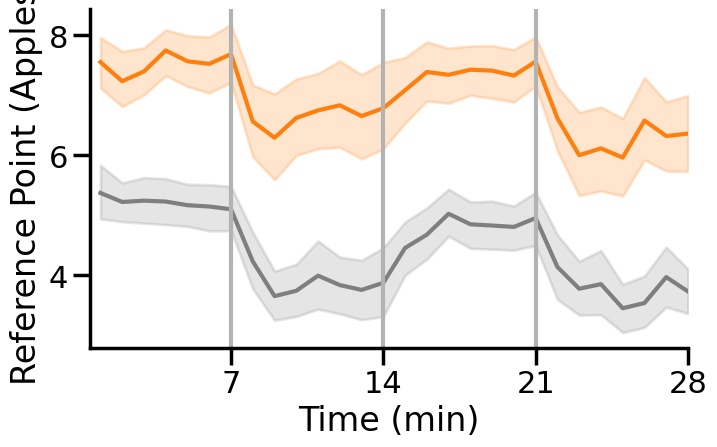

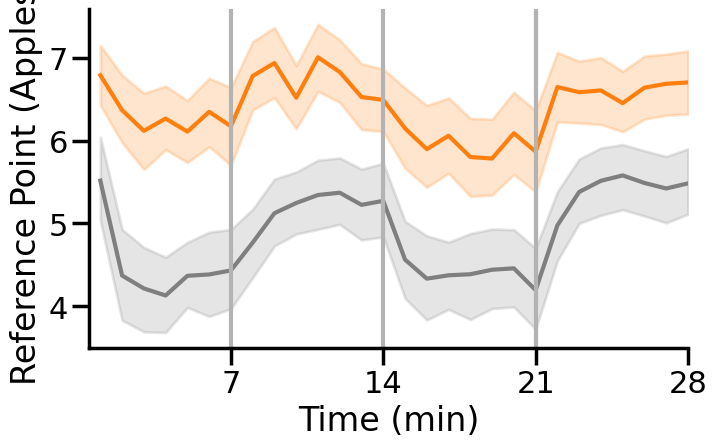

In [22]:
g = sns.relplot(data=dyn_data[dyn_data['firstBlock']=='short'], x='totalTimeBinnedMinutes', y='reward', hue='group', kind='line', aspect=1.5, legend=False)
g.map(plt.axvline, x=7, color='.7')
g.map(plt.axvline, x=14, color='.7')
g.map(plt.axvline, x=21, color='.7')
plt.ylabel('Reference Point (Apples)')
plt.xlabel('Time (min)')
g.ax.set_xticks([7,14,21,28])
plt.xlim(0.5,28)
# plt.rcParams['svg.fonttype'] = 'none'
# plt.savefig('fig1.svg')

g = sns.relplot(data=dyn_data[dyn_data['firstBlock']=='long'], x='totalTimeBinnedMinutes', y='reward', hue='group', kind='line', aspect=1.5, legend=False)
g.map(plt.axvline, x=7, color='.7')
g.map(plt.axvline, x=14, color='.7')
g.map(plt.axvline, x=21, color='.7')
plt.ylabel('Reference Point (Apples)')
plt.xlabel('Time (min)')
g.ax.set_xticks([7,14,21,28])
plt.xlim(0.5,28)

plt.show()
# plt.rcParams['svg.fonttype'] = 'none'
# plt.savefig('fig2.svg')

## Figure S3: Area under the curve (AUC) for short- and long-travel blocks over time.

In [23]:
foraging_calcs = pd.read_pickle('foraging_data.pkl')
data = pd.read_pickle('data.pkl')
foraging_calcs['id'] = foraging_calcs['id'].astype(int)
foraging_data = pd.merge(data[['id','group']], foraging_calcs, on='id',how='left') # cut to only data for valid participants

grouped = foraging_data.groupby(['id','date','patchBlock']) # group data by patient ID and date and block
left_thresholds = pd.DataFrame() # select all data one before a leave tree action
for name, group in grouped:
    pt_id = name[0]
    date = name[1]
    leftNum = 0 # threshold number in each block
    for i in group.index: # for each row in group
        if group.loc[i, 'decision'] == 'exit': # if exited
            leftNum += 1
            one_row_before = group.loc[i-1:i-1,:].copy()
            one_row_before['leftNum'] = leftNum
            left_thresholds = pd.concat((left_thresholds, one_row_before)) # add data from one row before


dyn_data = left_thresholds.copy()[['patchState', 'blockName','blockTime','patchBlock','time','reward','id','date','leftNum','totalCents']]
dyn_data.loc[:,'group'] = 'mdd'
dyn_data.loc[(dyn_data['id'] >= 2000),'group'] = 'control'
dyn_data['blockTimeBinned'] = (dyn_data['blockTime']//40)*40

# add modifier to show whether data is for firstBlock is a short block or a long block
dyn_data['firstBlock'] = 'short'
first_block_long_IDs = dyn_data[(dyn_data['blockName'] == 'long')&(dyn_data['patchBlock']==1)]['id'].unique()
dyn_data.loc[dyn_data['id'].isin(first_block_long_IDs), 'firstBlock'] = 'long'
dyn_data['firstBlock'].value_counts()

# add total time by multiplying number of blocks (minus 1) by 420 and adding to time (since all blocks are 420 seconds at most)
dyn_data['totalTime'] = 420*(dyn_data['patchBlock']-1) + dyn_data['blockTime']
dyn_data['totalTimeBinned'] = (dyn_data['totalTime']//60)*60
dyn_data['totalTimeBinnedMinutes'] = dyn_data['totalTimeBinned']/60+1

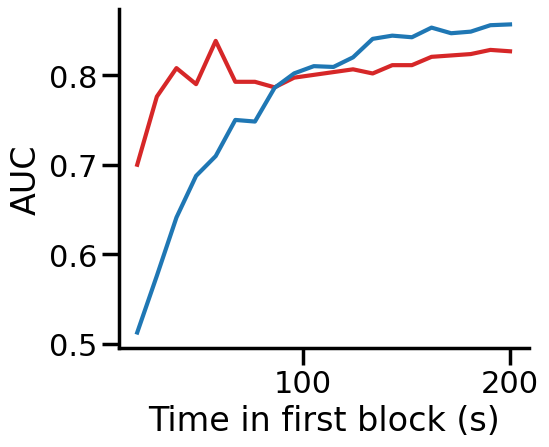

In [24]:
# how accurate is group classification by time in first block?
from sklearn.metrics import roc_curve, roc_auc_score
data_block1 = dyn_data[dyn_data['patchBlock']==1].copy()
time_thresh = np.linspace(20,200,num=20)
short_block_classify = []
long_block_classify = []
for thresh in time_thresh:
	df_cut = data_block1[data_block1['blockTime'] < thresh]
	df_cut = df_cut.groupby(['group','id','blockName'])['reward'].agg('mean').reset_index() # mean leaving threshold
	mdd_pred_short = df_cut[(df_cut['group']=='mdd')&(df_cut['blockName']=='short')]['reward'].to_list()
	control_pred_short = df_cut[(df_cut['group']=='control')&(df_cut['blockName']=='short')]['reward'].to_list()
	mdd_pred_long = df_cut[(df_cut['group']=='mdd')&(df_cut['blockName']=='long')]['reward'].to_list()
	control_pred_long = df_cut[(df_cut['group']=='control')&(df_cut['blockName']=='long')]['reward'].to_list()
	fpr, tpr, ts = roc_curve([0]*len(control_pred_short)+[1]*len(mdd_pred_short), control_pred_short+mdd_pred_short)
	auc = roc_auc_score([0]*len(control_pred_short)+[1]*len(mdd_pred_short), control_pred_short+mdd_pred_short)
	short_block_classify.append(auc)
	fpr, tpr, ts = roc_curve([0]*len(control_pred_long)+[1]*len(mdd_pred_long), control_pred_long+mdd_pred_long)
	auc = roc_auc_score([0]*len(control_pred_long)+[1]*len(mdd_pred_long), control_pred_long+mdd_pred_long)
	long_block_classify.append(auc)

auc_df = pd.DataFrame({'Time in first block (s)':list(time_thresh)+list(time_thresh), 
		'AUC':short_block_classify+long_block_classify, 
		'Block':['short']*len(time_thresh)+['long']*len(time_thresh)})
sns.set_palette(sns.color_palette(palette=['#d62728','#1f77b4']))
# sns.set_palette(sns.color_palette(palette=['#1f77b4']))
fig = sns.relplot(auc_df, x='Time in first block (s)', y='AUC', hue='Block', kind='line', aspect=1.2, legend=False)
fig.ax.set_xticks([100,200])
plt.show()
# plt.rcParams['svg.fonttype'] = 'none'
# plt.savefig('fig.svg')
# sns.set_palette(sns.color_palette(palette=['#ff7f0e','#7f7f7f','#1f77b4','#d62728']))


thresh_short 0.7868571428571428


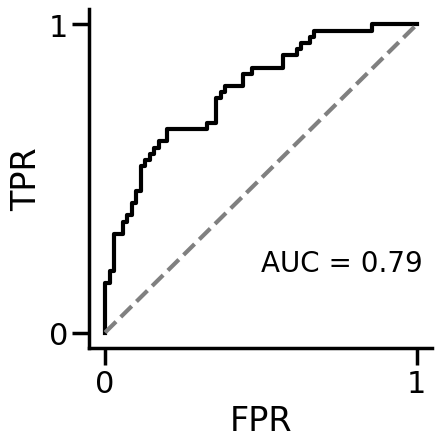

In [25]:
# for poster

from sklearn.metrics import roc_curve, roc_auc_score
# first test predictive ability of single threshold (either long/short/only for some blocks) by making AUC
sns.reset_defaults()
sns.set_palette(sns.color_palette(palette=['#000000','#ff7f0e','#1f77b4','#d62728']))
sns.set_context('poster')
predictors = ['thresh_short']
for pred in predictors:
	mdd_pred = data[data['group']=='mdd'][pred].to_list()
	control_pred = data[data['group']=='control'][pred].to_list()
	fpr, tpr, ts = roc_curve([0]*len(control_pred)+[1]*len(mdd_pred), control_pred+mdd_pred)
	auc = roc_auc_score([0]*len(control_pred)+[1]*len(mdd_pred), control_pred+mdd_pred)
	auc_curve = pd.DataFrame(np.array([fpr,tpr]).T, columns=['FPR','TPR'])
	
	fig = sns.relplot(data=auc_curve, x='FPR', y='TPR', estimator=None, kind='line', aspect=1.1)
	sns.lineplot(ax=fig.ax)
	fig.ax.set_xticks([0,1])
	fig.ax.set_yticks([0,1])
	fig.ax.plot(np.linspace(0,1), np.linspace(0,1),color='grey',linestyle='--')
	plt.text(0.5, 0.2, f'AUC = {auc:.2f}', fontsize=20)
	print(pred, auc)
	plt.show()
	# plt.rcParams['svg.fonttype'] = 'none'
	# fig.savefig('fig.svg')
	# fig.savefig('out.png',dpi=300)
# sns.reset_defaults()

## Figure S4: Foraging task reference point is reliable between blocks

In [26]:
foraging_calcs = pd.read_pickle('foraging_data.pkl')
data = pd.read_pickle('data.pkl')
foraging_calcs['id'] = foraging_calcs['id'].astype(int)
foraging_data = pd.merge(data[['id','group']], foraging_calcs, on='id',how='left') # cut to only data for valid participants

grouped = foraging_data.groupby(['id','date','patchBlock']) # group data by patient ID and date and block
left_thresholds = pd.DataFrame() # select all data one before a leave tree action
for name, group in grouped:
    pt_id = name[0]
    date = name[1]
    leftNum = 0 # threshold number in each block
    for i in group.index: # for each row in group
        if group.loc[i, 'decision'] == 'exit': # if exited
            leftNum += 1
            one_row_before = group.loc[i-1:i-1,:].copy()
            one_row_before['leftNum'] = leftNum
            left_thresholds = pd.concat((left_thresholds, one_row_before)) # add data from one row before


dyn_data = left_thresholds.copy()[['patchState', 'blockName','blockTime','patchBlock','time','reward','id','date','leftNum','totalCents']]
dyn_data.loc[:,'group'] = 'mdd'
dyn_data.loc[(dyn_data['id'] >= 2000),'group'] = 'control'
dyn_data['blockTimeBinned'] = (dyn_data['blockTime']//40)*40

# add modifier to show whether data is for firstBlock is a short block or a long block
dyn_data['firstBlock'] = 'short'
first_block_long_IDs = dyn_data[(dyn_data['blockName'] == 'long')&(dyn_data['patchBlock']==1)]['id'].unique()
dyn_data.loc[dyn_data['id'].isin(first_block_long_IDs), 'firstBlock'] = 'long'
dyn_data['firstBlock'].value_counts()

# add total time by multiplying number of blocks (minus 1) by 420 and adding to time (since all blocks are 420 seconds at most)
dyn_data['totalTime'] = 420*(dyn_data['patchBlock']-1) + dyn_data['blockTime']
dyn_data['totalTimeBinned'] = (dyn_data['totalTime']//60)*60
dyn_data['totalTimeBinnedMinutes'] = dyn_data['totalTimeBinned']/60+1

Linear regression result: LinregressResult(slope=np.float64(0.8377577977359659), intercept=np.float64(0.5105941839530455), rvalue=np.float64(0.842846627087174), pvalue=np.float64(1.5304814786819306e-33), stderr=np.float64(0.04924196457190193), intercept_stderr=np.float64(0.2513996931477762))


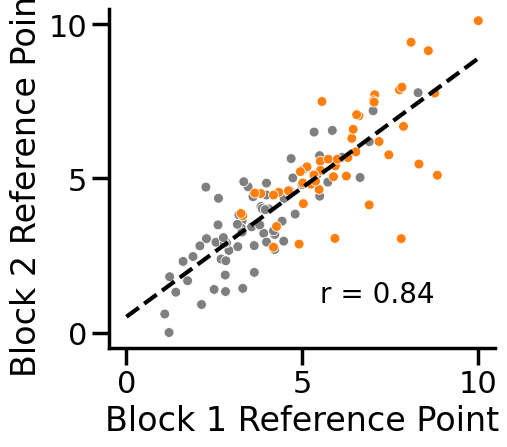

In [27]:
# how reliable is RP (first vs second block comparison)
rp_blocks = dyn_data[(dyn_data['blockName']=='long')].groupby(['group','id','patchBlock'])['reward'].agg('mean').reset_index()
rp_blocks['block'] = 1*(rp_blocks['patchBlock'] <= 2) + 2*(rp_blocks['patchBlock'] > 2)
rp_blocks = rp_blocks.pivot(values=['reward'], columns='block', index=['group','id'])
rp_blocks.columns = ['Block 1 Reference Point', 'Block 2 Reference Point']
rp_blocks = rp_blocks.reset_index()
rp_blocks
sns.set_palette(sns.color_palette(palette=['#7f7f7f','#ff7f0e']))
fig = sns.relplot(rp_blocks, x='Block 1 Reference Point', y='Block 2 Reference Point', hue='group', kind='scatter',s=50,aspect=1.2, legend=False)
result = stats.linregress(rp_blocks['Block 1 Reference Point'], rp_blocks['Block 2 Reference Point'])
print("Linear regression result:", result)
r_value = result.rvalue
plt.text(5.5, 1.0, f'r = {r_value:.2f}', fontsize=20)
plt.xlim(-0.5,10.5)
plt.ylim(-0.5,10.5)
fig.ax.set_xticks([0,5,10])
fig.ax.set_yticks([0,5,10])
fig.ax.plot(np.linspace(0,10), result.slope*np.linspace(0,10)+result.intercept,'k--')
plt.show()
sns.set_palette(sns.color_palette(palette=['#ff7f0e','#7f7f7f','#1f77b4','#d62728']))
# plt.rcParams['svg.fonttype'] = 'none'
# plt.savefig('fig.svg')

## Figure S5: Initial bidding shifts for both healthy controls and depressed participants.

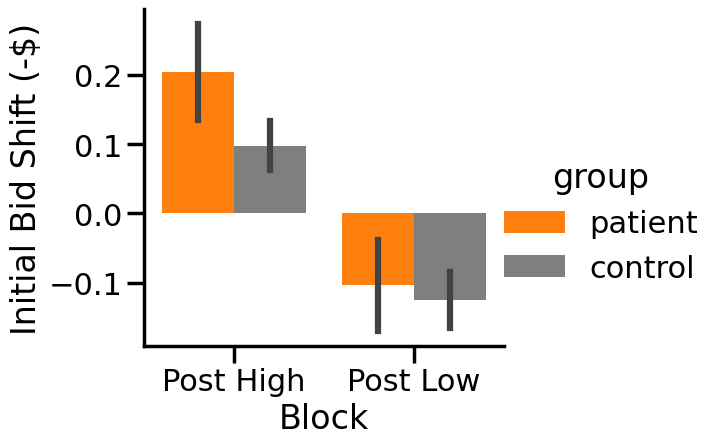

TtestResult(statistic=np.float64(-1.4880566479373774), pvalue=np.float64(0.06971313363412739), df=np.float64(117.0))
TtestResult(statistic=np.float64(-0.28348567501128447), pvalue=np.float64(0.6113493348650185), df=np.float64(118.0))


In [28]:
data_bidding = pd.read_pickle('bidding_data.pkl')
# average within subject out (so correct error bars)
data_bidding_by_sub = data_bidding.groupby(['binned_trial','block_meaning','group','subid'])['dev_from_lb'].agg('mean').reset_index()
data_bidding_by_sub = data_bidding_by_sub[data_bidding_by_sub['block_meaning'] != 'initial'] # keep only post high/post low blocks
data_bidding_by_sub = data_bidding_by_sub.rename(columns={'dev_from_lb':'Bid deviation ($)', 'binned_trial':'Trial'})
data_bidding_by_sub['Bid Shift (-$)'] = data_bidding_by_sub['Bid deviation ($)']*-1 # add column for bid shift (negative of bid deviation)

sns.set_palette(sns.color_palette(palette=['#ff7f0e','#7f7f7f','#1f77b4','#d62728']))
g = sns.catplot(data=data_bidding_by_sub[data_bidding_by_sub['Trial']==0],y='Bid Shift (-$)', x='block_meaning',hue='group',hue_order=['patient','control'],kind='bar',aspect=1.2,errorbar='se',saturation=1.0)#,native_scale=True,linestyle='none',markersize=6,capsize=0.15,err_kws={'linewidth':3},col_order=['control','patient'],hue_order=['post_low','post_high'])
plt.ylabel('Initial Bid Shift (-$)')
plt.xlabel('Block')
plt.xticks(ticks=[0,1],labels=['Post High','Post Low'])
# plt.rcParams['svg.fonttype'] = 'none'
# g.savefig('fig.svg')
plt.show()

# print statistics for group differences in first block
df_high = data_bidding_by_sub[(data_bidding_by_sub['Trial']==0)&(data_bidding_by_sub['block_meaning']=='post_high')]
df_low = data_bidding_by_sub[(data_bidding_by_sub['Trial']==0)&(data_bidding_by_sub['block_meaning']=='post_low')]
print(stats.ttest_ind(df_high[df_high['group']=='patient']['Bid deviation ($)'], df_high[df_high['group']=='control']['Bid deviation ($)'], alternative='less'))
print(stats.ttest_ind(df_low[df_low['group']=='patient']['Bid deviation ($)'], df_low[df_low['group']=='control']['Bid deviation ($)'], alternative='greater'))

## Figure S6: Reaction time is elevated in depressed patients but not correlated with depression severity.

t= 2.9822080507778512 p value= 0.001738730511576197
Pearson r: 0.16284552416022763 p-value: 0.25850594778280833


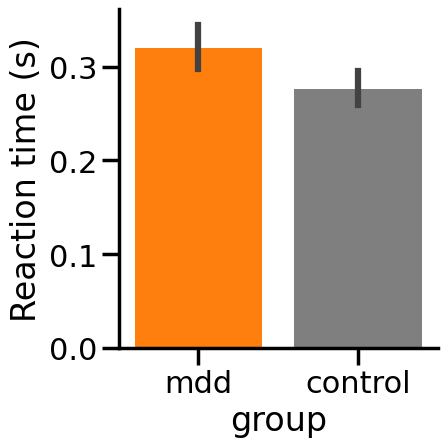

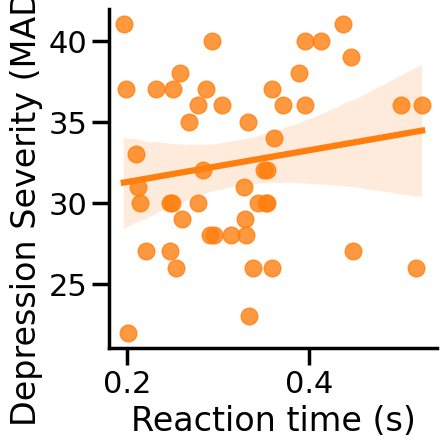

In [29]:
foraging_calcs = pd.read_pickle('foraging_data.pkl')
data = pd.read_pickle('data.pkl')
foraging_calcs['id'] = foraging_calcs['id'].astype(int)
foraging_data = pd.merge(data[['id','group']], foraging_calcs, on='id',how='left') # cut to only data for valid participants

avg_rt_per_pt = foraging_data.groupby(['id','group'])['rt'].agg('mean').reset_index()
sns.catplot(data=avg_rt_per_pt, x='group', y='rt', hue='group', kind='bar', saturation=1.0)
plt.ylabel('Reaction time (s)')

import scipy.stats as stats
t, pval = stats.ttest_ind(avg_rt_per_pt[avg_rt_per_pt['group']=='mdd']['rt'], avg_rt_per_pt[avg_rt_per_pt['group']=='control']['rt'], alternative='greater')
print('t=',t,'p value=',pval)

rt_and_madrs = pd.merge(avg_rt_per_pt, data[['id','madrs_score']], on='id', how='left')
sns.lmplot(data=rt_and_madrs, x='rt', y='madrs_score')
plt.xlabel('Reaction time (s)')
plt.ylabel('Depression Severity (MADRS)')
r_value, p_val = stats.pearsonr(rt_and_madrs[rt_and_madrs['group']=='mdd']["rt"], rt_and_madrs[rt_and_madrs['group']=='mdd']["madrs_score"])
print("Pearson r:", r_value, "p-value:", p_val)
plt.show()





## Figure S7: Estimated Raven’s score is elevated in controls compared to MDD patients but not correlated with depression severity

2-sample t-test for predicted Raven's score:
TtestResult(statistic=np.float64(-2.4373368256694077), pvalue=np.float64(0.008144045292663275), df=np.float64(118.0))
Pearson r: -0.06507155917139115 p-value: 0.6534577148920471


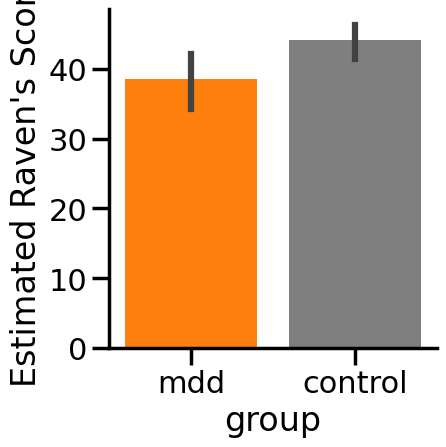

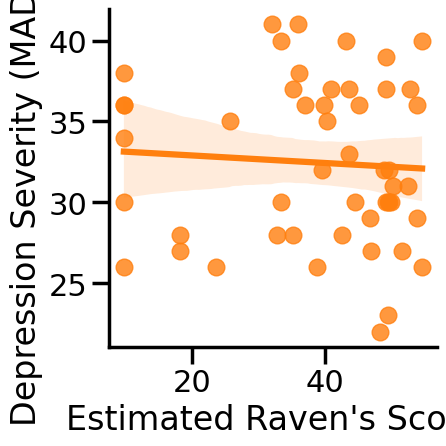

In [30]:
data = pd.read_pickle('data.pkl')
sns.catplot(data=data, x='group', y='predicted_ravens', hue='group', kind='bar', saturation=1)
plt.ylabel('Estimated Raven\'s Score')
# plt.rcParams['svg.fonttype'] = 'none'
# plt.savefig('ravens.svg')
# print statistics for group differences in predicted ravens
print('2-sample t-test for predicted Raven\'s score:')
print(stats.ttest_ind(data[data['group']=='mdd']['predicted_ravens'], data[data['group']=='control']['predicted_ravens'], alternative='less'))
mdd_data = data[data['group']=='mdd']
sns.lmplot(data=mdd_data, x='predicted_ravens', y='madrs_score')
plt.xlabel('Estimated Raven\'s Score')
plt.ylabel('Depression Severity (MADRS)')
# print correlation statistics for predicted ravens and madrs
r_value, p_val = stats.pearsonr(mdd_data["predicted_ravens"], mdd_data["madrs_score"])
print("Pearson r:", r_value, "p-value:", p_val)
# plt.rcParams['svg.fonttype'] = 'none'
# plt.savefig('ravens_vs_madrs.svg')
plt.show()